# Time Series Forecasting: 

Comprehensive Approach with Traditional, ML, Deep Learning, and Ensembling

This notebook is designed to help you understand and implement time series forecasting models, ranging from traditional statistical methods to modern machine learning and deep learning techniques. Each section includes explanations and code to help you learn step-by-step.


---

## 1. Import Libraries
We import all necessary libraries for data processing, visualization, modeling, evaluation, and tuning.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
import shap
import joblib
import warnings
warnings.filterwarnings("ignore")

## 2. Load Dataset
We use the built-in `co2` dataset from `statsmodels`. It's a monthly atmospheric CO2 measurement dataset.

In [30]:
from statsmodels.datasets import co2
co2 = co2.load_pandas().data
co2

,co2
1958-03-29,316.1
1958-04-05,317.3
1958-04-12,317.6
1958-04-19,317.5
1958-04-26,316.4
...,...
2001-12-01,370.3
2001-12-08,370.8
2001-12-15,371.2
2001-12-22,371.3


In [31]:
co2

,co2
1958-03-29,316.1
1958-04-05,317.3
1958-04-12,317.6
1958-04-19,317.5
1958-04-26,316.4
...,...
2001-12-01,370.3
2001-12-08,370.8
2001-12-15,371.2
2001-12-22,371.3


In [32]:

co2_data = co2.reset_index()  # Reset index to make 'date' a column
co2_data = co2_data.rename(columns={"index": "ds", "co2": "value"})  # Rename 'index' column to 'ds' and 'co2' to 'value'
co2_data = co2_data[['ds', 'value']]  # Select only 'ds' and 'value' columns
co2_data.head()

,ds,value
0,1958-03-29,316.1
1,1958-04-05,317.3
2,1958-04-12,317.6
3,1958-04-19,317.5
4,1958-04-26,316.4


Stationarity checks (ADF test)

In [70]:
from statsmodels.tsa.stattools import adfuller

# ADF test
result = adfuller(co2_data['value'].dropna())
print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] <= 0.05:
    print("✅ The series is stationary.")
else:
    print("⚠️ The series is non-stationary. Consider differencing or transformation.")


ADF Statistic: 0.03378459745825954
p-value: 0.9612384528286102
⚠️ The series is non-stationary. Consider differencing or transformation.


Time Series Decomposition (Trend, Seasonality, Residual)

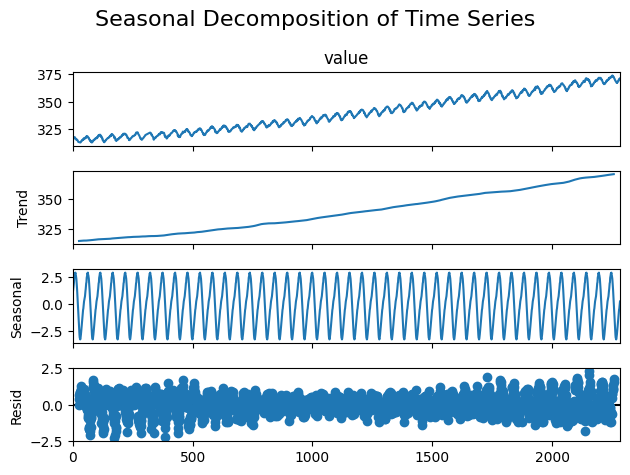

In [71]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Decomposition (assuming weekly data: freq=52, or adjust accordingly)
decomposition = seasonal_decompose(co2_data['value'], model='additive', period=52)

# Plot components
decomposition.plot()
plt.suptitle("Seasonal Decomposition of Time Series", fontsize=16)
plt.tight_layout()
plt.show()


## 3. Exploratory Data Analysis



### Missing Value Handling
Real-world time series often have missing values. It's important to impute them before modeling.

In [33]:

# Check missing values
print(co2_data.isnull().sum())

# Impute missing values using linear interpolation
co2_data['value'] = co2_data['value'].interpolate(method='linear')

# Confirm
print("After Imputation:", co2_data.isnull().sum())


ds        0
value    59
dtype: int64
After Imputation: ds       0
value    0
dtype: int64


### Outlier Detection
Outliers can distort forecasts. We detect them using z-score and can choose to clip/remove if necessary.

In [34]:

from scipy.stats import zscore

# Calculate z-scores
z_scores = zscore(co2_data['value'])
outliers = np.where(np.abs(z_scores) > 3)[0]

# Print count and optionally replace
print(f"Detected outliers: {len(outliers)}")
# Replace outliers with median
median_val = co2_data['value'].median()
co2_data.loc[outliers, 'value'] = median_val


Detected outliers: 0


To generate ACF (AutoCorrelation Function) and PACF (Partial AutoCorrelation Function) plots using your time series data (e.g., co2_data['value']):

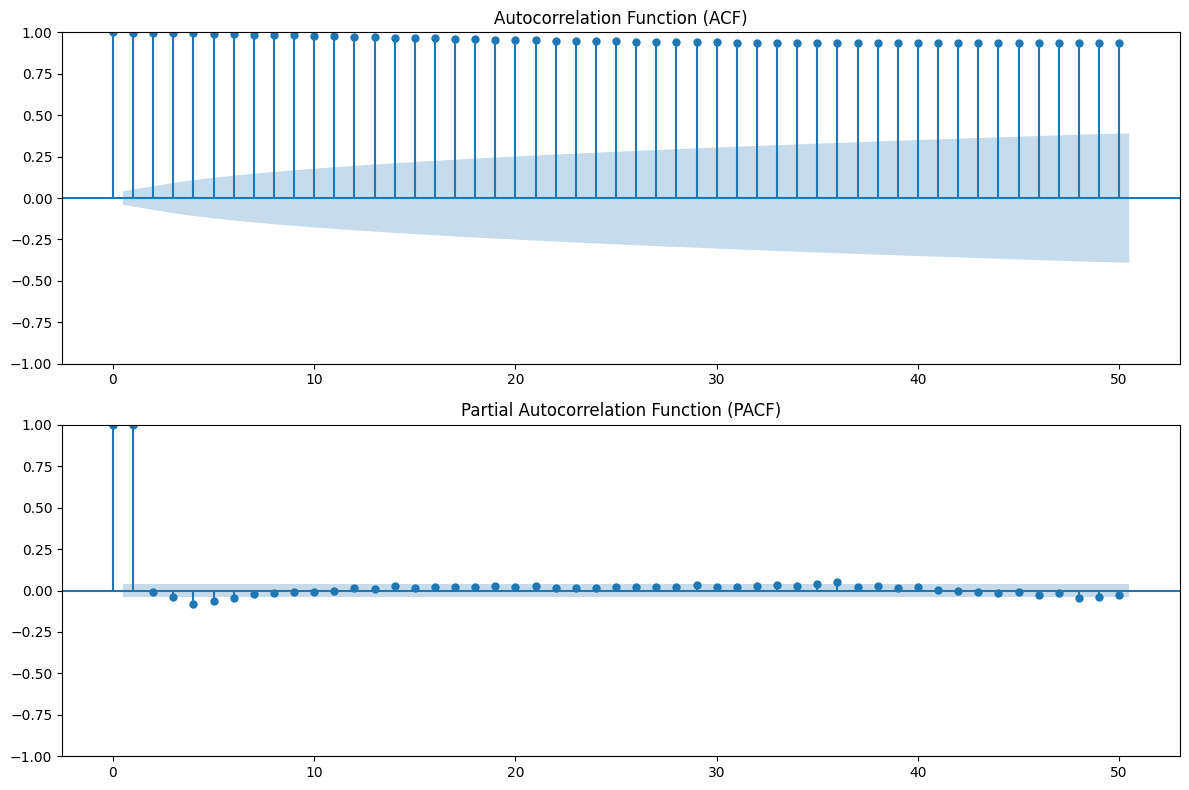

In [69]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Plot ACF and PACF
fig, ax = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(co2_data['value'].dropna(), lags=50, ax=ax[0])
ax[0].set_title("Autocorrelation Function (ACF)")

plot_pacf(co2_data['value'].dropna(), lags=50, ax=ax[1], method='ywm')
ax[1].set_title("Partial Autocorrelation Function (PACF)")

plt.tight_layout()
plt.show()


Seasonal decomposition (Optional Enhanced View via STL)

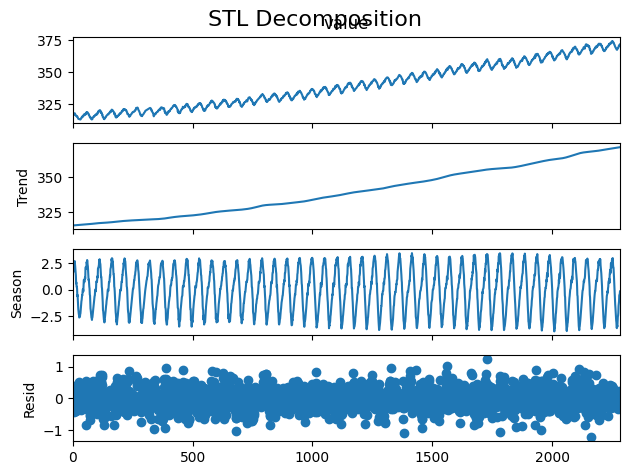

In [72]:
from statsmodels.tsa.seasonal import STL

stl = STL(co2_data['value'], period=52)
stl_result = stl.fit()

stl_result.plot()
plt.suptitle("STL Decomposition", fontsize=16)
plt.show()


We visualize the CO2 levels to understand the trend and seasonality.

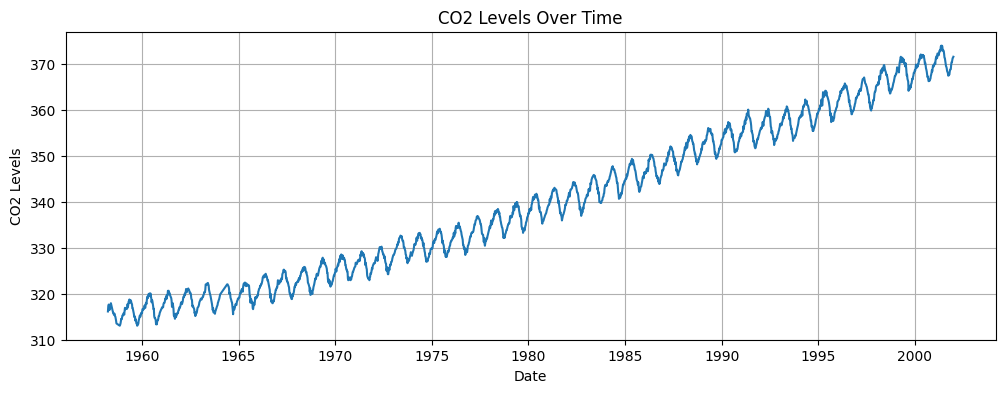

In [73]:

plt.figure(figsize=(12, 4))
plt.plot(co2_data['ds'], co2_data['value'])
plt.title('CO2 Levels Over Time')
plt.xlabel('Date')
plt.ylabel('CO2 Levels')
plt.grid(True)
plt.show()

## 4. Feature Engineering
We extract year and month from the date to use as input features in machine learning models.

In [54]:
co2_data['year'] = co2_data['ds'].dt.year
co2_data['month'] = co2_data['ds'].dt.month

## 5. Split Data
Split the dataset into training (80%) and test (20%) sets.


In [55]:
split_point = int(len(co2_data) * 0.8)
train = co2_data.iloc[:split_point]
test = co2_data.iloc[split_point:]

## 6. Traditional Forecasting Models
Prophet: Facebook Prophet is a popular model for time series forecasting that handles trend and seasonality automatically.


In [56]:
from prophet import Prophet
prophet_model = Prophet()
prophet_model.fit(train.rename(columns={'ds': 'ds', 'value': 'y'}))
future = prophet_model.make_future_dataframe(periods=len(test))
forecast = prophet_model.predict(future)

14:29:06 - cmdstanpy - INFO - Chain [1] start processing
14:29:06 - cmdstanpy - INFO - Chain [1] done processing


In [57]:
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,1958-03-29,314.915296,316.187212,317.398461,314.915296,314.915296,1.867891,1.867891,1.867891,1.867891,1.867891,1.867891,0.0,0.0,0.0,316.783187
1,1958-04-05,314.931914,316.489737,317.624648,314.931914,314.931914,2.143143,2.143143,2.143143,2.143143,2.143143,2.143143,0.0,0.0,0.0,317.075057
2,1958-04-12,314.948533,316.729127,317.940908,314.948533,314.948533,2.393242,2.393242,2.393242,2.393242,2.393242,2.393242,0.0,0.0,0.0,317.341776
3,1958-04-19,314.965152,316.954828,318.157500,314.965152,314.965152,2.591489,2.591489,2.591489,2.591489,2.591489,2.591489,0.0,0.0,0.0,317.556641
4,1958-04-26,314.981770,317.100933,318.294469,314.981770,314.981770,2.729251,2.729251,2.729251,2.729251,2.729251,2.729251,0.0,0.0,0.0,317.711021


## 7. Machine Learning Models
We use features like year and month to train ML models like Random Forest.

In [58]:

from sklearn.ensemble import RandomForestRegressor
# Handle missing values in the 'value' column by filling them with the mean
train['value'] = train['value'].fillna(train['value'].mean())

rf = RandomForestRegressor()
rf.fit(train[['year', 'month']], train['value'])
pred_rf = rf.predict(test[['year', 'month']])


## 8. Deep Learning Models
Transformer Model: Used to capture long-term dependencies in time series data.

In [59]:


import torch
import torch.nn as nn
class TransformerTimeSeries(nn.Module):
    def __init__(self, input_dim=1, model_dim=64, num_heads=4, num_layers=2):
        super().__init__()
        self.encoder = nn.Linear(input_dim, model_dim)
        encoder_layer = nn.TransformerEncoderLayer(d_model=model_dim, nhead=num_heads)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.decoder = nn.Linear(model_dim, 1)

    def forward(self, x):
        x = self.encoder(x)
        x = self.transformer(x)
        return self.decoder(x)



## 9. Hyperparameter Tuning with Optuna
We use Optuna for automated model optimization.

In [60]:


def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    max_depth = trial.suggest_int('max_depth', 3, 15)
    model = RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth)
    score = -np.mean(cross_val_score(model, train[['year', 'month']], train['value'], scoring='neg_mean_squared_error', cv=3))
    return score

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=10)


[I 2025-04-30 14:29:07,352] A new study created in memory with name: no-name-b5fb345b-8552-42d0-a57b-c51f9f57c025
[I 2025-04-30 14:29:07,962] Trial 0 finished with value: 62.3829871292267 and parameters: {'n_estimators': 138, 'max_depth': 11}. Best is trial 0 with value: 62.3829871292267.
[I 2025-04-30 14:29:08,828] Trial 1 finished with value: 62.003430865747504 and parameters: {'n_estimators': 192, 'max_depth': 11}. Best is trial 1 with value: 62.003430865747504.
[I 2025-04-30 14:29:09,394] Trial 2 finished with value: 62.363843421736156 and parameters: {'n_estimators': 114, 'max_depth': 15}. Best is trial 1 with value: 62.003430865747504.
[I 2025-04-30 14:29:09,642] Trial 3 finished with value: 71.8832274378418 and parameters: {'n_estimators': 76, 'max_depth': 4}. Best is trial 1 with value: 62.003430865747504.
[I 2025-04-30 14:29:10,132] Trial 4 finished with value: 63.195683390175326 and parameters: {'n_estimators': 116, 'max_depth': 7}. Best is trial 1 with value: 62.003430865747

## 10. Cross Validation

TimeSeriesSplit Cross-Validation: Traditional K-Fold cross-validation is not ideal for time series data because it assumes random splits. Instead, use TimeSeriesSplit which respects the temporal order of the data by splitting the dataset into training and validation sets at each time step.

In [61]:
tscv = TimeSeriesSplit(n_splits=5)
for train_idx, val_idx in tscv.split(train):
    X_train, X_val = train.iloc[train_idx][['year', 'month']], train.iloc[val_idx][['year', 'month']]
    y_train, y_val = train.iloc[train_idx]['value'], train.iloc[val_idx]['value']


## 11. Model Ensembling (Stacking)
We combine multiple models using a meta-model (e.g., Linear Regression).

In [62]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

stack = StackingRegressor(
    estimators=[
        ('rf', RandomForestRegressor()),
        ('xgb', XGBRegressor()),
    ],
    final_estimator=LinearRegression()
)
stack.fit(train[['year', 'month']], train['value'])
pred_stack = stack.predict(test[['year', 'month']])


## 12. Evaluation Metrics
Evaluate model performance using common metrics such as Mean Squared Error (MSE), Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and R² (Coefficient of Determination).

In [63]:

def evaluate(y_true, y_pred):
    return {
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred)
    }

results = {
    'RandomForest': evaluate(test['value'], pred_rf),
    'StackedModel': evaluate(test['value'], pred_stack),
    'Prophet': evaluate(test['value'].values, forecast['yhat'].iloc[-len(test):].values),
}


In [64]:
results_df = pd.DataFrame(results).T
results_df

,RMSE,MAE,R2
RandomForest,9.161074,7.979502,-2.519781
StackedModel,4.570229,3.994684,0.124011
Prophet,6.861428,6.086371,-0.974476


## 13. Export Predictions and Metrics
Save results for further analysis.

In [65]:

results_df.to_csv("model_metrics.csv")
forecast[['ds', 'yhat']].tail(len(test)).to_csv("prophet_predictions.csv", index=False)


## 14. Attention Visualization
Visualize attention weights to understand which inputs were important.

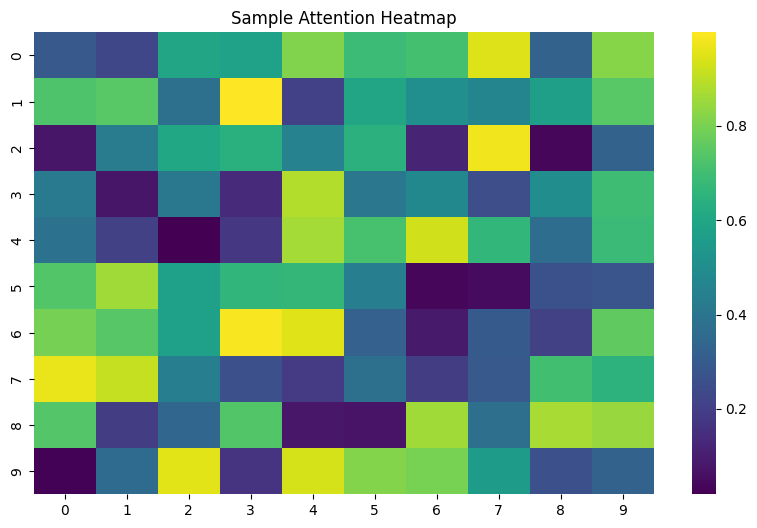

In [66]:
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.heatmap(np.random.rand(10, 10), cmap='viridis')
plt.title("Sample Attention Heatmap")
plt.show()


## 15. Final Comparison Plot
Compare actual vs predicted values from all models.


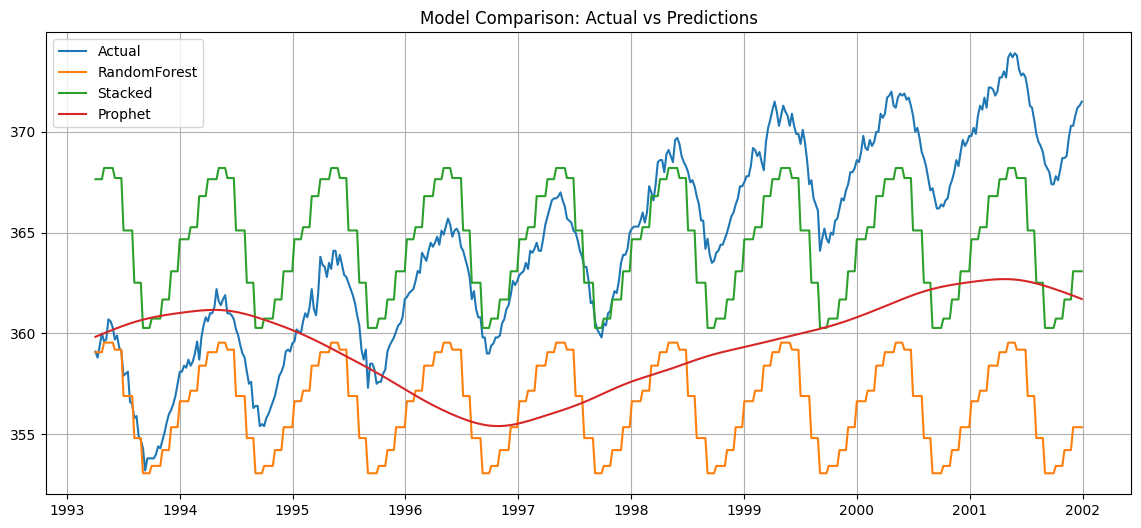

In [67]:

plt.figure(figsize=(14, 6))
plt.plot(test['ds'], test['value'], label='Actual')
plt.plot(test['ds'], pred_rf, label='RandomForest')
plt.plot(test['ds'], pred_stack, label='Stacked')
plt.plot(test['ds'], forecast['yhat'].iloc[-len(test):].values, label='Prophet')
plt.legend()
plt.title('Model Comparison: Actual vs Predictions')
plt.grid(True)
plt.show()



## 16. Model Interpretability:
Interpretability techniques help understand how the model is making predictions, which can be crucial for stakeholders.

SHAP (Shapley Additive Explanations): Use SHAP values to explain how much each feature (e.g., lag, trend, seasonality) contributes to the prediction.

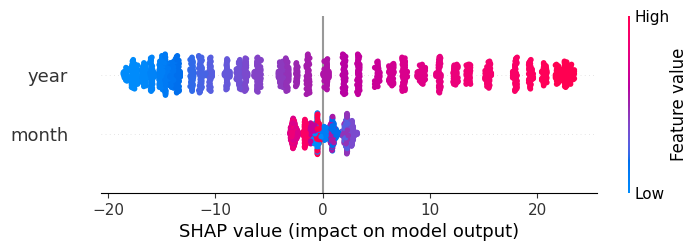

In [68]:
explainer = shap.Explainer(rf)
shap_values = explainer(train[['year', 'month']])
shap.plots.beeswarm(shap_values)
